In [1]:
from sklearn.neighbors import LocalOutlierFactor
import numpy as np # Ensure numpy is imported for np.where
import pandas as pd # Import pandas to load DataFrame

# 3. Density based outlier detection using - (Chosen) Local outlier Factor (LOF)
threshold = -6

# Ensure 'data' is defined from the DataFrame 'df'
# Load df if not already loaded
DATASET_PATH = "./housing.csv"
# Download the dataset if it's not present
import os
if not os.path.exists(DATASET_PATH):
    print(f"Downloading {DATASET_PATH}...")
    !gdown 1Yhw8tBCmjYrDZ5Rm1xPrP2y5bmBmxoEP
    print(f"{DATASET_PATH} downloaded.")
df = pd.read_csv(DATASET_PATH)
data = df["SalePrice"]

lof = LocalOutlierFactor(n_neighbors=10)
lof.fit(data.to_frame())
lof_scores = lof.negative_outlier_factor_
outlier_indices = np.where(lof_scores < threshold)[0]
outlier_points = data[outlier_indices]

outlier_points

Downloading...
From: https://drive.google.com/uc?id=1Yhw8tBCmjYrDZ5Rm1xPrP2y5bmBmxoEP
To: /content/housing.csv
100% 461k/461k [00:00<00:00, 29.4MB/s]
./housing.csv downloaded.


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


,SalePrice
8,129900
21,139400
23,129900
26,134800
43,130250
...,...
1327,130500
1344,155835
1352,134900
1360,189000


This code snippet performs Density-Based Outlier Detection using the Local Outlier Factor (LOF) algorithm on your SalePrice data. Here's a breakdown of what each part does:

# 3. Density based outlier detection using - (Chosen) Local outlier Factor (LOF):

This is a comment indicating the method chosen for outlier detection.
threshold = -6:

This line sets a threshold value. In LOF, smaller (more negative) negative_outlier_factor_ values indicate a higher likelihood of being an outlier. This specific threshold of -6 will be used to determine which points are considered outliers.
lof = LocalOutlierFactor(n_neighbors=10):

This initializes the LocalOutlierFactor model from scikit-learn. The n_neighbors=10 parameter specifies that for each point, the algorithm will consider its 10 nearest neighbors to calculate its local density and compare it with its neighbors' densities.
lof.fit(data.to_frame()):

This step fits the LOF model to your data. data.to_frame() converts your SalePrice Series into a DataFrame, which is the expected input format for the fit method. During this fitting, the model computes the local reachability density for each sample.
lof_scores = lof.negative_outlier_factor_:

After fitting, the negative_outlier_factor_ attribute contains the opposite of the LOF score for each data point. A value close to -1 indicates that the sample is similar to its neighbors (not an outlier), while significantly lower (more negative) values indicate a lower local density than its neighbors, thus making it an outlier.
outlier_indices = np.where(lof_scores < threshold)[0]:

This line identifies the indices of the data points that are considered outliers. It selects all points whose negative_outlier_factor_ is less than the threshold of -6. np.where() returns a tuple of arrays, and [0] extracts the array of indices.
outlier_points = data[outlier_indices]:

Using the identified outlier_indices, this line extracts the actual SalePrice values from your original data Series that correspond to these outlier points.
outlier_points:

This line will display the pandas Series containing the SalePrice values that have been identified as outliers by the LOF algorithm.

In [ ]:
# Analysis and removal techniques of outliers from dataset
#
# 1. Visual analysis of the Univariate data to observe extreme values in the data
#    a. Distplot (Histplot)
#    b. Boxplots/Whisker plots
#    c. Scatter plot
#
# 2. Distance based outlier detection - K-NN based outlier detection
#
# 3.
#
#`n
#
#

In [3]:
# Download the dataset file to local storage (from publicly shared drive file)
# Original source: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques
# (The rest of the notebook expects the original housing.csv to be present in the current directory)
!gdown 1Yhw8tBCmjYrDZ5Rm1xPrP2y5bmBmxoEP

Downloading...
From: https://drive.google.com/uc?id=1Yhw8tBCmjYrDZ5Rm1xPrP2y5bmBmxoEP
To: /content/housing.csv
100% 461k/461k [00:00<00:00, 108MB/s]


In [4]:
# Import required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import LocalOutlierFactor

In [5]:
# Load the dataset
import pandas as pd
DATASET_PATH = "./housing.csv"
df = pd.read_csv(DATASET_PATH)
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [ ]:
# 1. Visual analysis of the Univariate data to observe extreme values in the data

In [6]:
# Select the data for for analysis/outlier detection
data = df["SalePrice"]
data

,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000
...,...
1455,175000
1456,210000
1457,266500
1458,142125


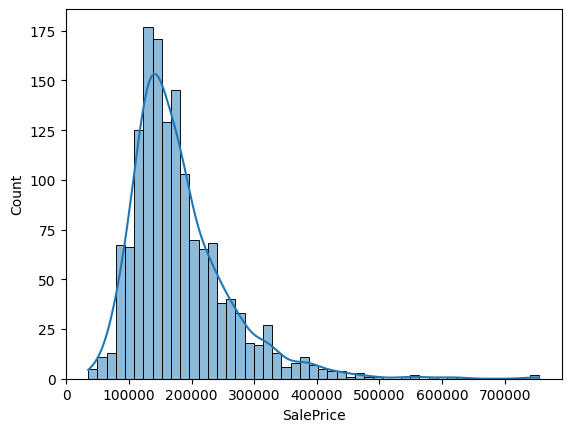

In [7]:
# a. Distplot using Histplot
sns.histplot(data, kde=True)
pass

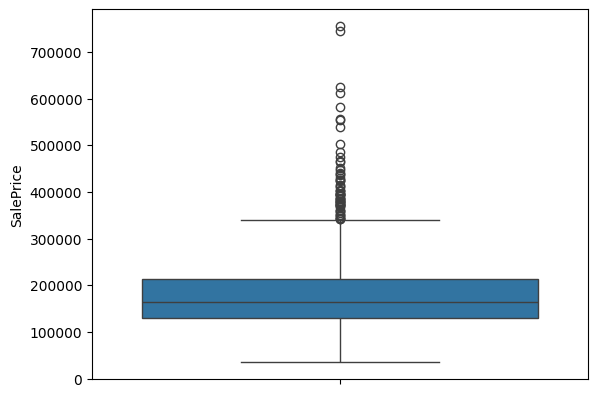

In [8]:
# b. Boxplots/ Whisker plots
sns.boxplot(data)
pass

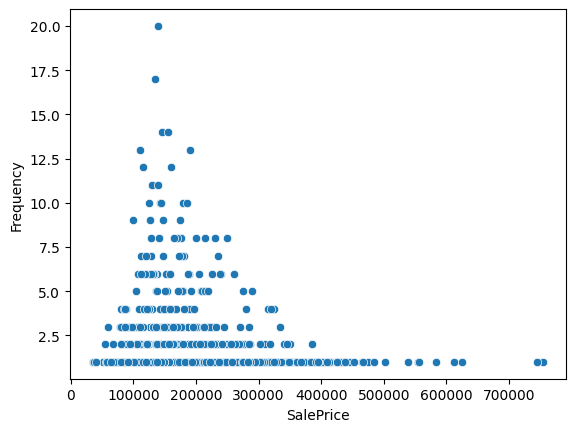

In [9]:
# c. Scatter plot
#
# from matplotlib.ticker import MaxNLocator # to ensure the graph show int on y axis (can b)
# fig, ax = plt.subplots()
# ax.yaxis.set_major_locator(MaxNLocator(integer=True))

sns.scatterplot(data.value_counts())
# plt.xlabel('SalePrice')
plt.ylabel('Frequency')
pass

In [ ]:
# 2. Distance based outlier detection - K-NN based outlier detection

In [10]:
model = NearestNeighbors(n_neighbors=10)
model.fit(data.to_frame())

# Find distances to k nearest neighbors for each point
distances, _ = model.kneighbors(data.to_frame())

# Compute outlier score as the distance to the kth nearest neighbor
outlier_score = distances[:, -1]

# Set threshold for outlier detection
threshold = np.percentile(outlier_score, 95)

# Identify outliers
outliers = data[outlier_score > threshold]
outliers

,SalePrice
29,68500
30,40000
53,385000
58,438780
112,383970
...,...
1337,52500
1353,410000
1373,466500
1388,377500


Certainly! This code snippet performs K-Nearest Neighbors (k-NN) based outlier detection on your SalePrice data. Here's a breakdown of what each part does:

model = NearestNeighbors(n_neighbors=10):

This line initializes a NearestNeighbors model from scikit-learn. It's configured to find the 10 nearest neighbors for each data point.
model.fit(data.to_frame()):

The model is trained using your data (which is the 'SalePrice' column). data.to_frame() converts the pandas Series into a DataFrame, which is the expected input format for the fit method.
distances, _ = model.kneighbors(data.to_frame()):

This step calculates the distances from each data point to its 10 nearest neighbors. distances will be an array where each row corresponds to a data point, and columns contain the distances to its neighbors, sorted from closest to furthest. The _ is used to ignore the indices of the neighbors, as we only need the distances here.
outlier_score = distances[:, -1]:

For each data point, its outlier score is determined by the distance to its k-th (in this case, 10th) nearest neighbor. If a point is far from its 10th neighbor, it's considered more isolated and thus more likely to be an outlier. This line extracts that 10th distance for every point.
threshold = np.percentile(outlier_score, 95):

A threshold for identifying outliers is set. Here, the 95th percentile of all calculated outlier scores is chosen. This means that data points with an outlier score higher than this value will be considered outliers.
outliers = data[outlier_score > threshold]:

Finally, this line identifies and extracts the actual data points from your original data Series that have an outlier_score greater than the calculated threshold. These are your detected outliers.

In [11]:
# 3. Density based outlier detection using - (Chosen) Local outlier Factor (LOF)
threshold = -6

lof = LocalOutlierFactor(n_neighbors=10)
lof.fit(data.to_frame())
lof_scores = lof.negative_outlier_factor_
outlier_indices = np.where(lof_scores < threshold)[0]
outlier_points = data[outlier_indices]

outlier_points

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


,SalePrice
8,129900
21,139400
23,129900
26,134800
43,130250
...,...
1327,130500
1344,155835
1352,134900
1360,189000


In [ ]:
# 4) Remove outliers using trimming and capping (Winsorization)
trimming_threshold_percent = 10

lower_bound = np.percentile(data, trimming_threshold_percent)
upper_bound = np.percentile(data, 100 - trimming_threshold_percent)

# a) Trimming (based on percentile)
trimmed_data = data[(data > lower_bound) & (data < upper_bound)]
trimmed_data

,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000
...,...
1455,175000
1456,210000
1457,266500
1458,142125


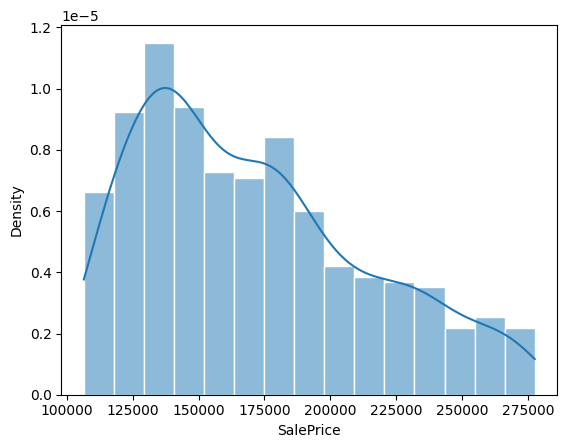

In [ ]:
# Distplot on trimmed data
sns.histplot(trimmed_data, kde=True, stat="density", ec='w')
pass

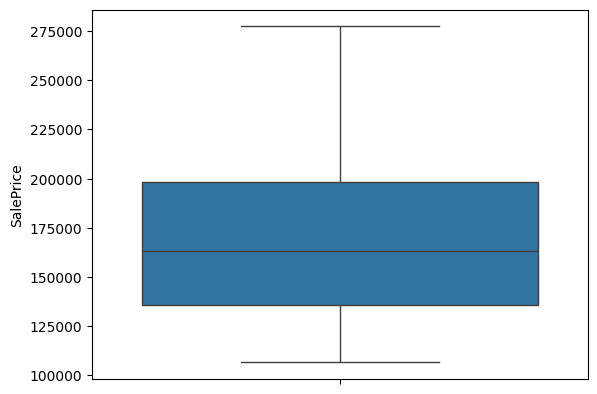

In [ ]:
# Boxplots/ Whisker plots on trimmed data
sns.boxplot(trimmed_data)
pass

In [ ]:
# b) Winsorization (based on percentile)
capping_threshold_percent = 10

lower_bound = np.percentile(data, capping_threshold_percent)
upper_bound = np.percentile(data, 100 - capping_threshold_percent)

capped_data = np.clip(data, lower_bound, upper_bound)
capped_data

,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000
...,...
1455,175000
1456,210000
1457,266500
1458,142125


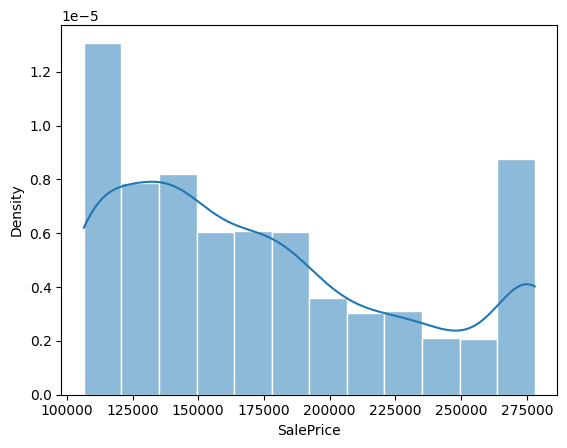

In [ ]:
# Distplot on capped data
sns.histplot(capped_data, kde=True, stat="density", ec='w')
pass

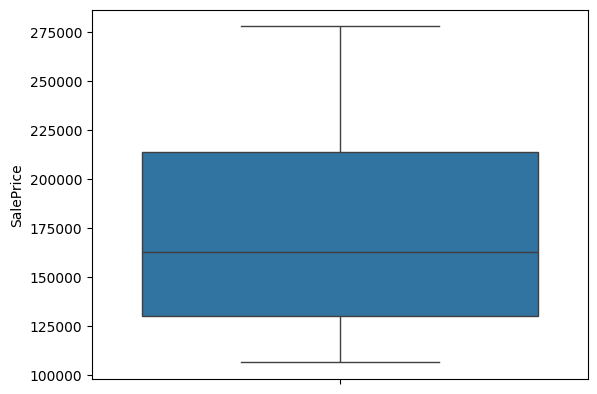

In [ ]:
# Boxplots/ Whisker plots on capped data
sns.boxplot(capped_data)
pass